In [ ]:
!pip install -q timm sentence-transformers easyocr xgboost lightgbm joblib imbalanced-learn
!pip install -q tensorflow==2.19.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 963.8/963.8 kB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 28.2 MB/s eta 0:00:00


1. Import Required Libraries

In [ ]:
# Standard imports
import os
import zipfile
import numpy as np
import joblib
import pickle
from tqdm import tqdm

# ML / DL
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, regularizers, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, precision_recall_curve

import xgboost as xgb
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE

# Vision / Text feature libs
import cv2
from PIL import Image
import torch
import timm
from sentence_transformers import SentenceTransformer
import easyocr

# Repro reproducibility
SEED = 42
np.random.seed(SEED)
import random
random.seed(SEED)
tf.random.set_seed(SEED)

2. Dataset Preparation

In [ ]:
    zip_path = '/content/drive/MyDrive/datasets.zip'
    extract_dir = '/content/datasets'

    if os.path.exists(zip_path) and not os.path.exists(extract_dir):
        print('Extracting dataset...')
        os.makedirs(extract_dir, exist_ok=True)
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(extract_dir)
        print('Extracted to', extract_dir)
    else:
        print('No zip found at', zip_path)

Extracting dataset...
Extracted to /content/datasets


3. Data Preprocessing 

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device for torch:', device)

vit_model = timm.create_model('vit_base_patch16_224', pretrained=True)
vit_model.head = torch.nn.Identity()
vit_model.eval()
vit_model.to(device)

from torchvision import transforms
vit_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

reader = easyocr.Reader(['en'], gpu=(device=='cuda'))
text_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

def extract_vit_features(image_paths):
    """Accepts list of image paths and returns (N, D_vit) array."""
    feats = []
    with torch.no_grad():
        for p in tqdm(image_paths, desc='ViT'):
            img = cv2.imread(p)
            if img is None:
                print('Warning: could not read', p); continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = Image.fromarray(img)
            t = vit_transform(img).unsqueeze(0).to(device)
            v = vit_model(t).cpu().numpy().reshape(-1)
            feats.append(v)
    return np.vstack(feats)


def extract_ocr_features(image_paths):
    """Accepts list of image paths and returns (N, D_ocr) array."""
    feats = []
    for p in tqdm(image_paths, desc='OCR'):
        try:
            res = reader.readtext(p, detail=0)
            text = " ".join(res).lower()
            text = "".join([c if c.isalnum() or c==' ' else ' ' for c in text])
            emb = text_model.encode(text)
            feats.append(emb)
        except Exception as e:
            print('OCR error on', p, e)
            feats.append(np.zeros(text_model.get_sentence_embedding_dimension()))
    return np.vstack(feats)

Device for torch: cuda


4. Feature Extraction

In [ ]:
genuine_dir = os.path.join(extract_dir, 'datasets', 'screenshots', 'genuine_site_0')
phishing_dir = os.path.join(extract_dir, 'datasets', 'screenshots', 'phishing_site_1')

genuine_paths = sorted([os.path.join(genuine_dir, f) for f in os.listdir(genuine_dir)])
phishing_paths = sorted([os.path.join(phishing_dir, f) for f in os.listdir(phishing_dir)])

print('Found genuine:', len(genuine_paths), 'phishing:', len(phishing_paths))

print("Extracting ViT + OCR features...")

vit_genuine = extract_vit_features(genuine_paths)
vit_phishing = extract_vit_features(phishing_paths)
ocr_genuine = extract_ocr_features(genuine_paths)
ocr_phishing = extract_ocr_features(phishing_paths)

X_genuine = np.concatenate([vit_genuine, ocr_genuine], axis=1)
X_phishing = np.concatenate([vit_phishing, ocr_phishing], axis=1) 

X_fused = np.vstack([X_genuine, X_phishing]).astype('float32')
y_all = np.array([0]*len(X_genuine) + [1]*len(X_phishing))
print("Final feature shape:", X_fused.shape)

np.save('/content/X_fused.npy', X_fused)
np.save('/content/y_all.npy', y_all)

Found genuine: 1147 phishing: 550
✅ Extracting ViT + OCR features...


OCR: 100%|██████████| 550/550 [03:38<00:00,  2.52it/s]

✅ Final feature shape: (1697, 1152)


5. Train-Test Split

In [ ]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_fused, y_all, test_size=0.25, stratify=y_all, random_state=SEED
)
print('Train/test shapes:', X_train_full.shape, X_test.shape)

X_train_genuine = X_train_full[y_train_full == 0]
print('AE training data (genuine only):', X_train_genuine.shape)

scaler = StandardScaler()
scaler.fit(X_train_full)
X_train_full = scaler.transform(X_train_full).astype('float32')
X_test = scaler.transform(X_test).astype('float32')
X_train_genuine = scaler.transform(X_train_genuine).astype('float32')

Train/test shapes: (1272, 1152) (425, 1152)
AE training data (genuine only): (860, 1152)


6. Model Training

In [ ]:
input_dim = X_train_genuine.shape[1]
encoding_dim = 32 

inp = layers.Input(shape=(input_dim,))
x = layers.Dropout(0.2)(inp)
x = layers.Dense(256, activation='relu', kernel_regularizer='l1')(x)
x = layers.Dense(128, activation='relu')(x)
latent = layers.Dense(encoding_dim, activation='relu', name='latent')(x)
x = layers.Dense(128, activation='relu')(latent)
x = layers.Dense(256, activation='relu')(x)
out = layers.Dense(input_dim, activation='linear')(x)

autoencoder = models.Model(inp, out)
encoder = models.Model(inp, latent)

autoencoder.compile(optimizer='adam', loss='mse')
ae_history = autoencoder.fit(X_train_genuine, X_train_genuine,
                epochs=20, batch_size=32, shuffle=True,
                validation_split=0.2, callbacks=[
                    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
                ])

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 177ms/step - loss: 82.5392 - val_loss: 44.3687
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 35.1013 - val_loss: 13.0450
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.0393 - val_loss: 3.0575
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5447 - val_loss: 1.7448
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5681 - val_loss: 1.5215
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.4424 - val_loss: 1.4476
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.3770 - val_loss: 1.4749
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.3712 - val_loss: 1.4393
Epoch 9/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.3700 - val_loss: 1.3869
Epoch 10/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.3240 - val_loss: 1.3922
Epoch 11/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.3017 - val_loss: 1.4077
Epoch 12/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.3329 -

7. Reconstruction error features + fuse for supervised training

In [ ]:
latent_train = encoder.predict(X_train_full)
latent_test = encoder.predict(X_test)
recon_train = autoencoder.predict(X_train_full)
recon_test = autoencoder.predict(X_test)

mse_train = np.mean(np.square(X_train_full - recon_train), axis=1).reshape(-1,1)
mse_test = np.mean(np.square(X_test - recon_test), axis=1).reshape(-1,1)

X_train_supervised = np.concatenate([X_train_full, latent_train, mse_train], axis=1)
X_test_supervised = np.concatenate([X_test, latent_test, mse_test], axis=1)

print('Supervised fused shapes:', X_train_supervised.shape, X_test_supervised.shape)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Supervised fused shapes: (1272, 1185) (425, 1185)


8. SMOTE Balancing

In [ ]:
print('Before SMOTE:', np.bincount(y_train_full.astype(int)))
sm = SMOTE(random_state=SEED)
X_train_bal, y_train_bal = sm.fit_resample(X_train_supervised, y_train_full)
print('After SMOTE:', np.bincount(y_train_bal.astype(int)))

X_train_for_model = X_train_bal
y_train_for_model = y_train_bal

Before SMOTE: [860 412]
After SMOTE: [860 860]


9. Train XGBoost and LightGBM (base learners)

In [ ]:
xgb_clf = xgb.XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=6,
    subsample=0.9, colsample_bytree=0.9, use_label_encoder=False, eval_metric='logloss', random_state=SEED
)

lgb_clf = LGBMClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=6, subsample=0.9, colsample_bytree=0.9, random_state=SEED
)

print('Training XGB...')
xgb_clf.fit(X_train_for_model, y_train_for_model)
print('Training LGB...')
lgb_clf.fit(X_train_for_model, y_train_for_model)

xgb_train_proba = xgb_clf.predict_proba(X_train_supervised)[:,1]
lgb_train_proba = lgb_clf.predict_proba(X_train_supervised)[:,1]

xgb_test_proba = xgb_clf.predict_proba(X_test_supervised)[:,1]
lgb_test_proba = lgb_clf.predict_proba(X_test_supervised)[:,1]

meta_train = np.vstack([xgb_train_proba, lgb_train_proba]).T
meta_test = np.vstack([xgb_test_proba, lgb_test_proba]).T

Training XGB...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:41:08] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training LGB...
[LightGBM] [Info] Number of positive: 860, number of negative: 860
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022402 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 300603
[LightGBM] [Info] Number of data points in the train set: 1720, number of used features: 1180
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


10. Stacking Ensemble (XGBoost + LGBM + Meta-Classifier)

In [ ]:
print("Training base models (XGBoost + LGBM)...")

meta_clf = LogisticRegression(max_iter=300, solver='lbfgs', random_state=SEED)
meta_clf.fit(meta_train, y_train_full)

val_preds = meta_clf.predict_proba(meta_test)[:, 1]
val_labels = (val_preds >= 0.5).astype(int)

print("\nMeta-Classifier Validation Performance:")
print(classification_report(y_test, val_labels, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, val_labels))
print("ROC-AUC:", roc_auc_score(y_test, val_preds))
print("F1 Score:", f1_score(y_test, val_labels))

✅ Training base models (XGBoost + LGBM)...

📊 Meta-Classifier Validation Performance:
              precision    recall  f1-score   support

           0     0.8427    0.8397    0.8412       287
           1     0.6691    0.6739    0.6715       138

    accuracy                         0.7859       425
   macro avg     0.7559    0.7568    0.7563       425
weighted avg     0.7863    0.7859    0.7861       425

Confusion Matrix:
 [[241  46]
 [ 45  93]]
ROC-AUC: 0.8591122557188305
F1 Score: 0.6714801444043321


11. Threshold Optimization

In [ ]:
print("Optimizing threshold for best F1...")

prec, rec, thr = precision_recall_curve(y_test, val_preds)
f1 = 2 * (prec * rec) / (prec + rec + 1e-8)
best_idx = np.nanargmax(f1)
best_thr = thr[best_idx]

print(f"Best threshold: {best_thr:.4f}")
print(f"Precision: {prec[best_idx]:.4f}, Recall: {rec[best_idx]:.4f}, F1: {f1[best_idx]:.4f}")

tuned_preds = (val_preds >= best_thr).astype(int)
print("\nTuned Threshold Performance:")
print(classification_report(y_test, tuned_preds, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, tuned_preds))
print("ROC-AUC:", roc_auc_score(y_test, val_preds))

🔎 Optimizing threshold for best F1...
✅ Best threshold: 0.0585
Precision: 0.6384, Recall: 0.8188, F1: 0.7175

📈 Tuned Threshold Performance:
              precision    recall  f1-score   support

           0     0.8992    0.7770    0.8336       287
           1     0.6384    0.8188    0.7175       138

    accuracy                         0.7906       425
   macro avg     0.7688    0.7979    0.7756       425
weighted avg     0.8145    0.7906    0.7959       425

Confusion Matrix:
 [[223  64]
 [ 25 113]]
ROC-AUC: 0.8591122557188305


12. Saving Final Model and Artifacts

In [ ]:
save_dir = '/content/final_stack_models'
os.makedirs(save_dir, exist_ok=True)

autoencoder.save(os.path.join(save_dir, 'autoencoder.keras'))
encoder.save(os.path.join(save_dir, 'encoder.keras'))

joblib.dump(xgb_clf, os.path.join(save_dir, 'xgb_model.pkl'))
joblib.dump(lgb_clf, os.path.join(save_dir, 'lgbm_model.pkl'))

joblib.dump(meta_clf, os.path.join(save_dir, 'meta_clf.pkl'))

joblib.dump(scaler, os.path.join(save_dir, 'scaler.pkl'))

with open(os.path.join(save_dir, 'best_threshold.pkl'), 'wb') as f:
    pickle.dump(best_thr, f)

print(f'All models and artifacts saved successfully in: {save_dir}')
print('If needed, copy to Google Drive to persist across sessions:')
print('!cp -r /content/final_stack_models /content/drive/MyDrive/')

✅ All models and artifacts saved successfully in: /content/final_stack_models
If needed, copy to Google Drive to persist across sessions:
!cp -r /content/final_stack_models /content/drive/MyDrive/


In [ ]:
!cp -r /content/final_stack_models /content/drive/MyDrive/

13. Single Image inference (Upload + Predict)

Saving microsoft_phish.jpg to microsoft_phish.jpg
✅ Uploaded image: microsoft_phish.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

🌐 Prediction: Phishing
🔹 Confidence: 0.0068


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


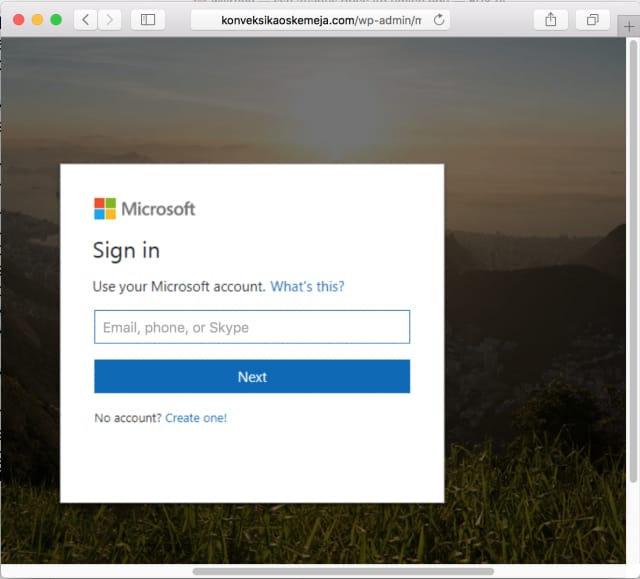

In [ ]:
from google.colab import files
def extract_vit_single(path):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = Image.fromarray(img)
    t = vit_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        feat = vit_model(t).cpu().numpy().reshape(1, -1)
    return feat

def extract_ocr_single(path):
    res = reader.readtext(path, detail=0)
    text = ' '.join(res).lower()
    text = ''.join([c if c.isalnum() or c == ' ' else ' ' for c in text])
    emb = text_model.encode(text).reshape(1, -1)
    return emb

uploaded = files.upload()
if not uploaded:
    raise RuntimeError('Please upload one screenshot image.')

img_path = list(uploaded.keys())[0]
print(f'Uploaded image: {img_path}')

vit_feat = extract_vit_single(img_path)
ocr_feat = extract_ocr_single(img_path)
fused_feat = np.concatenate([vit_feat, ocr_feat], axis=1).astype('float32')

fused_scaled = scaler.transform(fused_feat)

latent = encoder.predict(fused_scaled)
recon = autoencoder.predict(fused_scaled)
mse = np.mean(np.square(fused_scaled - recon), axis=1).reshape(-1,1)

X_predict = np.concatenate([fused_scaled, latent, mse], axis=1)

xgb_p = xgb_clf.predict_proba(X_predict)[:, 1]
lgb_p = lgb_clf.predict_proba(X_predict)[:, 1]

meta_input = np.vstack([xgb_p, lgb_p]).T
meta_p = meta_clf.predict_proba(meta_input)[:, 1]

label = "Phishing" if meta_p[0] >= best_thr else "Genuine"
print(f"\nPrediction: {label}")
print(f"Confidence: {meta_p[0]:.4f}")

from IPython.display import Image as IPyImage, display
display(IPyImage(filename=img_path))